# Regularization: Ridge, Lasso, and Elastic Net

We now turn to **supervised machine learning** and **Chapters 3 and 10 from our Hull textbook**. We'll use these methods to predict housing prices using data that has already been cleaned and scaled.

We'll see **Ridge regression**, **Lasso regression**, and **Elastic Net** -- three techniques that help deal with having **too many correlated features** in a model. These methods add a **penalty** to the regression to shrink or eliminate coefficients, producing simpler and often better-predicting models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score as r2


## Linear regression and prediction. More Hull, Chapters 3 and 10.

Chapter 3 starts off with the math behind linear regression with one feature. This is what we did in the previous section, when we tried to explain pricing errors with one variable using `statsmodels`. This math and how regression works should be familiar from your introductory statistics course. 

The notes below walk you through what's in Hull in more detail.

### Machine learning and prediction

We're going to introduce **machine learning concepts** now. Notice the idea of a **training set**. This is the data that we use to create our model. We are then going to take the outputs (i.e. the coefficients) from this model and use it to predict values in the **out-of-sample** data.

In machine learning applications, we have an **X** dataframe and a **y** dataframe. The **X** dataframe has all of our features. They are typically standardized. This means doing something like taking every numerical feature and turning it into a **z-score**. 

The **y** is the **target** variable. The thing that you are trying to predict. You'll also standardize this, typically. 

And, crucially, the **X** data frame **only** contains the features we want. No extra columns. Nothing that we used earlier to create a new variable. If it is in **X**, then it is going into the model. This is different from using other packages or languages, where you might write out your regression model. In fact, we did that in the previous section when using `statsmodels`. 

**Why don't people write out their models in machine learning? Too many variables and the algo is picking your model for you!**

The textbook introduces the idea of **three different types of data sets: training, validation, and testing**. Let's ask Claude about the differences:

In machine learning, data is typically split into three subsets: training data, validation data, and test data. Each subset serves a different purpose in the model development and evaluation process.

**Training Data**: The training data is the largest portion of the dataset, and it is used to train the machine learning model. During the training process, the model learns patterns and relationships from the training data. The model's parameters are adjusted to minimize the error or loss function on this data.

**Validation Data**: The validation data is a subset of the data held out from the training process. It is used to evaluate the performance of the model during the training phase. The validation data provides an unbiased estimate of the model's performance on unseen data. It helps tune the **hyperparameters** of the model, such as the learning rate, regularization strength, or the number of iterations. The validation data is used to prevent **overfitting**, which occurs when the model performs well on the training data but fails to generalize to new, unseen data. By monitoring the performance on the validation data, early stopping or regularization techniques can be applied to improve the model's generalization capability.

**Test Data**: The test data is a separate subset of the data that is completely isolated from the training and validation processes. It is used to evaluate the final performance of the trained model on unseen data, providing an unbiased estimate of the model's real-world performance. The test data should be representative of the data the model will encounter in production or real-world scenarios. The performance metrics calculated on the test data, such as accuracy, precision, recall, or F1-score, are considered the final, reliable indicators of the model's effectiveness.

It is crucial to keep the test data separate and untouched during the training and validation phases to avoid any data leakage or overfitting to the test data. The test data should only be used once, after the model has been fully trained and tuned, to obtain an unbiased estimate of its performance.

By splitting the data into these three subsets, machine learning practitioners can train models effectively, tune hyperparameters, and evaluate the final performance objectively, ensuring that the model will generalize well to new, unseen data.

As you'll see, sometimes we only use two separate data sets, training and test data. We'll validate the model within the training data. 

`sklearn` has many built-in features to help, like ways to automatically split your data, though the textbook tends to do things manually. 

Chapter 3.2 introduces **multiple features**. Again, this just means multiple explanatory X variables. Eq. 3.1 gives us the general form of a linear regression model:

\begin{align}
Y = a + b_1 X_1 + b_2 X_2 + \cdots + b_m X_m + \varepsilon
\end{align}

The [statsmodel](https://www.statsmodels.org/dev/examples/notebooks/generated/ols.html) page for linear regression has helpful code examples, including how to generate dummy variables (see below).

### Important regression statistics

What is regression trying to do? Hull discusses these linear models from the machine learning perspective. So, rather than a discussion of the [Gauss-Markov theorem and BLUE](https://en.wikipedia.org/wiki/Gauss–Markov_theorem), we get something less theoretical. 

In short, the linear regression algorithm selects values for $a$ and each $b$ above that minimize the sum of the squared differences between each Y and its predicted value (i.e. the right-hand side of the equation). This is shown in Eq. 3.2. Why do we square the differences? The direction of the error doesn't matter - we want predicted values to be close to the actual value. 

The text notes that $a$ is called the model **bias** and the $b$ values are called the model **weights**. In econometrics, we call $a$ the **intercept** and the $b$ values **coefficients**. 

Machine learning techniques are all about **prediction**. How well does the model predict or fit the data? To measure this, we can use the **R-Squared** value for the model. 

\begin{align}
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
\end{align}

We can also put this into words:

\begin{align}
R^2 = 1 - \frac{\text{Variance of the errors } \epsilon}{\text{Variation of the observations on the target Y}}
\end{align}

As noted by the text:

> The R-squared statistic is between zero and one and measures the proportion of the variance in the target that is explained by the features.

This is a statistic for the entire model. We also care about how well each feature (variable) does in explaining the variation in our outcome/target/Y variable. We use *t*-statistics for that. 

Again, from the text:

> The *t*-statistic of the $a$ or $𝑏_𝑗$ parameters estimated by a linear regression is the value of the parameter divided by its standard error. The P-value is the probability of obtaining a *t*-statistic as large as the one observed if we were in the situation where the parameter had no explanatory power at all. A P-value of 5% or less is generally considered as indicating that the parameter is significant. If the P-value for the parameter $b_j$ in equation (3.1) is less than 5%, we are over 95% confident that the feature $X_j$ has some effect on Y. The critical t-statistic for 95% confidence when the data set is large is 1.96 (i.e., t-statistics greater than  1.96 are significant in the sense that they give rise to P-values less than 5%).

I would take issue with some of the language in that explanation. These values are about relationships and correlations, but I see *effect* in that description. Saying that these correlations are actually causal relationships requires assumptions that go beyond pure statistics. You need a model. In our case, this would mean an economic model that describes incentives and behavior.

### Categorical features, again

We saw these in the previous section, when we used *bedroomcnt*. From the Hull text:

> A common practice is to use the same number of dummy variables as there are categories and associate each dummy variable with a particular category. The value of a dummy variable is one if the corresponding category applies and zero otherwise. This is referred to as **one-hot encoding**.

We used `pd.get_dummies` above to one-hot encode some indicators.

The text also discusses the **dummy variable trap**. If you create a dummy variable for each categorical value and then add a constant to the regression model, your model is **overfit** and will not estimate. In economics, we usually include a constant or intercept term in our regressions. This isn't always the case in machine learning. 

To avoid this trap, **drop one of the indicators for the set**. So, suppose that you've taken a variable called *Color* that gets your three indicators for *Color_Red*, *Color_Green*, or 
*Color_Blue*. **Every** observation has a 1 in one of those columns and zeroes in the others. Drop one of the indicators, like *Color_Red* - remove the column from your data frame. Your model will now run.

By doing this, the *Color_Red* observations are those where *Color_Green* and *Color_Blue* are both zero. *Color_Green* and *Color_Blue* are estimated relative to *Color_Red*. For example, if the coefficient for *Color_Green* is 0.5, the y-variable is shifted by 0.5 when *Color_Green* is equal to one, relative to the default prediction for the *Color_Red*.

As noted above, though, in machine learning, we often don't spend a lot of time interpreting the coefficients like this. Instead, we want to include as much information as possible in order to make a prediction. Get your model to run and focus on the predicted y variables.

### Regularization and Ridge regression

These next three methods come from the machine learning literature and help to deal with having **too many explanatory variables**. When I say this, I mean that they come more from the computer science and statistics world than the econometrics world. This distinction is meaningful if you're trained in one set of methods vs. another, but is becoming less important over time as machine learning and econometrics borrow from each other. 

```{margin} What is econometrics?
Econometrics is usually interested in causal relationships among economic agents. So, does more schooling increase wages, or do the people who are good at school also earn more? These are difficult questions to answer and economists have developed a variety of tools to help. If you've taken econometrics, then you've seen topics like instrumental variables and difference-in-differences. In economics, we're more interested in explaining why something is happening than predicting an outcome. So, did a change in a zoning law affect housing prices, rather than predicting a pricing error. 
```

Why are too many explanatory (X) variables a problem? They make the math harder when different X variables are correlated with one another. In other words, we have different features in our data that are really explaining the same thing. The book uses the area of the basement and the area of the first floor of a house as an example. These values are different, but capture the same thing, generally speaking - house size. 

**Regularization** helps us reduce the number of variables used in our model. We are also going to see more **scaling** of features. It is important to scale (e.g. Z-score) in order for different features to be comparable with each other. 

A larger, positive z-score means that the observation is above the mean value for that feature (X) or target (y). Vice-versa for negative values. Values are centered around zero after scaling this way. As Hull notes, there are other ways to scale variables, but this Z-score method is very common.

Here's a [sklearn article](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html) on the importance of scaling your features before using them in a machine learning model. From the article:

> Feature scaling through standardization, also called Z-score normalization, is an important preprocessing step for many machine learning algorithms. It involves rescaling each feature such that it has a standard deviation of 1 and a mean of 0.

One way to regularize our model is to use a **Ridge regression**. This algorithm chooses $a$ and $b$ parameters to minimize this function:


\begin{align}
\frac{1}{n}\sum_{i=1}^{n}(Y_i - a - b_1X_{i1} - b_2X_{i2} - \cdots - b_mX_{im})^2 + \lambda\sum_{j=1}^{m}b_j^2
\end{align}

Note that this looks a lot like a normal regression, except that we now have the last term with $\lambda$ and $b^2$. From the text:

> This change has the effect of encouraging the model to keep the weights $b_j$ as small as possible. It is **shrinking** the coefficients.

This method is also called **L2 regularization**. Why do we do this? From the text:

> L2 regularization is one way of avoiding the situation such as that in equation (3.3) where there are two correlated features, one with a large positive weight and the other with a large negative weight. Its general effect is to **simplify a linear regression model**. Sometimes, the model obtained after regularization generalizes better than the model before regularization. 

How do we choose a value for $\lambda$? From the text:

> The parameter $\lambda$ is referred to as a **hyperparameter** because it is used as a tool to determine the best model but is not part of the model itself. The choice of a value for $\lambda$ is obviously important. A large value for λ would lead to all the $b_j$ being set equal to zero. (The resulting model would then be uninteresting as it would always predict a value equal to $a$ for Y.) In practice, it is desirable to try several different values for $\lambda$ and choose between the resulting models.

If $\lambda$ is set to zero, then we have linear regression. As you increase $\lambda$, the model will become **less complex**.

Take a look at **footnote 3**. `sklearn` uses the **sum of squared errors** rather than the **mean sum of squared errors**. In other words, there's no $\frac{1}{n}$ out in front of the Ridge regression formula. So, you have to multiply your lambda term by *n*, or the number of observations, when using it. See more below, where I work the example in the Hull text.

### LASSO regression

From the Hull text:

> In Ridge, we added a constant times the sum of the squared weights to the objective function. In LASSO, we add a constant times the sum of the **absolute weights**.

LASSO is also called **L1 regularization**. This changes the last term in the equation that we are trying to minimize:

\begin{align}
\frac{1}{n}\sum_{i=1}^{n}(Y_i - a - b_1X_{i1} - b_2X_{i2} - \cdots - b_mX_{im})^2 + \lambda\sum_{j=1}^{m}|b_j|
\end{align}

I asked Claude to explain this equation:

This equation represents the objective function for LASSO (Least Absolute Shrinkage and Selection Operator) regression. LASSO is a type of linear regression that uses L1 regularization to add a penalty term to the cost function. This penalty term encourages sparse solutions, driving some coefficient estimates to exactly zero, effectively performing variable selection and improving interpretability of the model. The first term is the regular least squares error term that measures the model's fit to the data. The second term is the L1 regularization penalty on the sum of the absolute values of the coefficients ($|b_j|$), multiplied by a tuning parameter lambda that controls the strength of the penalty.

By minimizing this objective function, LASSO regression aims to find the best fit linear model while also promoting sparsity in the coefficients, making it useful for scenarios with many potential predictor variables.

Using LASSO is going to mean having more $b = 0$ values. In other words, some features are "kicked out of the model" in order to simplify things. This is going to happen when **certain features explain the same variation in the Y variable**. 

Again, check out footnote 4 for some details on how LASSO works in `sklearn`.

### Elastic net regression

Elastic Net regression is a **mixture of Ridge and LASSO**. The function to be minimized includes both a constant times the sum of the squared weights and a different constant times the sum of the absolute values of the weights.

\begin{align}
\frac{1}{n}\sum_{i=1}^{n}(Y_i - a - b_1X_{i1} - b_2X_{i2} - \cdots - b_mX_{im})^2 + \lambda_1\sum_{j=1}^{m}b_j^2 + \lambda_2\sum_{j=1}^{m}|b_j|
\end{align}

From the text:

> In LASSO some weights are set to zero, but others may be quite large in magnitude. In Ridge, weights are small in magnitude, but they are not reduced to zero. The idea underlying Elastic Net is that we may be able to get the **best of both worlds** by making some weights zero while reducing the magnitude of the others.

From Claude:

This equation represents the objective function for Elastic Net regularization, which is a linear regression model that combines the L1 (LASSO) and L2 (Ridge) regularization techniques. The first term is the standard mean squared error term, which measures the difference between the predicted values and the actual target values ($Y_i$) for the given data points ($X_{i1}$, $X_{i2}$, ..., $X_{im}$). 

The second term is the L2 regularization penalty, also known as the Ridge penalty, which adds the sum of the squared coefficients ($b_j^2$) multiplied by a tuning parameter $λ_1$. This penalty encourages small coefficient values and helps to prevent overfitting.

The third term is the L1 regularization penalty, also known as the LASSO penalty, which adds the sum of the absolute values of the coefficients ($|b_j|$) multiplied by a tuning parameter $λ_2$. This penalty promotes sparsity in the model by driving some coefficients to exactly zero, effectively performing variable selection.

By combining the L1 and L2 penalties, Elastic Net regularization aims to benefit from the strengths of both Ridge and LASSO regularization. It can handle correlated predictors better than LASSO and can select more predictive features than Ridge regression. The tuning parameters $λ_1$ and $λ_2$ control the relative importance of the L1 and L2 penalties, respectively. Elastic Net regularization is particularly useful when dealing with high-dimensional data with potentially correlated predictors, where both variable selection and coefficient shrinkage are desirable.

## Using our tools to predict housing prices

I'm going to replicate the Hull textbook results below. This data has housing sale prices and features about each house. The houses are in Iowa and represent sales over a four year period. The data has already been scaled, so that each feature has a mean of 0 and a standard deviation of 1. As noted above, you should use the means and standard deviations from the training data to scale the testing data.

The text describes the data and its structure. We are going to create training, validation, and testing data sets. Note that the data are already cleaned up for you. If you were doing this on your own, you'd need to do the steps described on pg. 65. 

You do this in our lab assignments.

Notice how this is a different question from the Zillow data. We're directly predicting housing prices here, not Zillow's pricing errors. Zillow was trying to identify the types of houses that were difficult to price using their Zestimate model.

In [2]:
# Both features and target have already been scaled: mean = 0; SD = 1
data = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/Houseprice_data_scaled.csv') 

We are going to split this data into **training** and **validation** sets. We'll estimate the model on the training data and then check it using the validation set. Note the use of `.iloc`. 

In [3]:
# First 1800 data items are training set; the next 600 are the validation set
train = data.iloc[:1800] 
val = data.iloc[1800:2400]

When we split the data like this, we're assuming that the data are already randomly shuffled. In practice, this probably isn't a great assumption. `sklearn` has built-in tools to do this.

We then separate the X and Y variables into two different data sets. This is the way the `sklearn` package wants things.

In [4]:
# Creating the "X" and "y" variables. We drop sale price from "X"
X_train, X_val = train.drop('Sale Price', axis=1), val.drop('Sale Price', axis=1)
y_train, y_val = train[['Sale Price']], val[['Sale Price']] 

In [5]:
y_train.head()

,Sale Price
0,0.358489
1,0.008849
2,0.552733
3,-0.528560
4,0.895898


In [6]:
X_train.head()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,NWAmes,OLDTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Bsmt Qual
0,-0.199572,0.652747,-0.512407,1.038851,0.875754,0.597837,-0.937245,-0.482464,-0.808820,1.203988,...,-0.23069,-0.286942,-0.136621,-0.2253,-0.214192,-0.268378,-0.127929,-0.152629,-0.091644,0.584308
1,-0.072005,-0.072527,2.189741,0.136810,-0.432225,1.218528,-0.635042,0.490326,0.276358,-0.789421,...,-0.23069,-0.286942,-0.136621,-0.2253,-0.214192,-0.268378,-0.127929,-0.152629,10.905682,0.584308
2,0.111026,0.652747,-0.512407,0.972033,0.827310,0.095808,-0.296754,-0.329118,-0.637758,1.231999,...,-0.23069,-0.286942,-0.136621,-0.2253,-0.214192,-0.268378,-0.127929,-0.152629,-0.091644,0.584308
3,-0.077551,0.652747,-0.512407,-1.901135,-0.722887,-0.520319,-0.057698,-0.722067,-0.528171,0.975236,...,-0.23069,-0.286942,-0.136621,-0.2253,-0.214192,-0.268378,-0.127929,-0.152629,-0.091644,-0.577852
4,0.444919,1.378022,-0.512407,0.938624,0.730423,0.481458,-0.170461,0.209990,-0.036366,1.668495,...,-0.23069,-0.286942,-0.136621,-0.2253,-0.214192,-0.268378,-0.127929,-0.152629,-0.091644,0.584308


Now we can create the model. We are creating a linear regression object from the `sklearn` library. We then fit the model using our X and y training data. The results live inside of this object.

**See how there's no equation?** All of the features that I want to include are in the `X_train` data frame. My target variable is in `y_train`. I'm using the features to predict my target.

You cannot do this step unless those two data frames are exactly what you want, no extra columns, everything is numeric, etc.

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
type(lr)

sklearn.linear_model._base.LinearRegression

We can pull values out of this model, but they aren't easy to read. 

In [9]:
lr.intercept_

array([-3.0633583e-11])

In [10]:
lr.coef_

array([[ 0.07899962,  0.21439487,  0.09647867,  0.16079944,  0.02535241,
         0.09146643, -0.03307981,  0.13819939,  0.15278604,  0.13276527,
         0.16130303, -0.02080763,  0.0171941 , -0.08352025,  0.08322035,
         0.02825777,  0.03799712,  0.05180927,  0.02083365,  0.03409815,
         0.00682223, -0.01843054, -0.01292138, -0.02462624,  0.02076177,
        -0.00737828, -0.00675362,  0.03632347, -0.00069006, -0.00834022,
        -0.00153683, -0.01641797, -0.02848206, -0.03850568,  0.05156257,
        -0.0219519 ,  0.12398991, -0.05175909, -0.02649903, -0.00414298,
        -0.01813409, -0.02827543,  0.02750632,  0.06305863, -0.00276173,
         0.00240311,  0.01131146]])

Let's put that same information into an easier-to-read DataFrame. We can output the coefficients, or $b$ values, from the model, along with the intercept, or $a$ value.

In [11]:
# Create dataFrame with corresponding feature and its respective coefficients
coeffs = pd.DataFrame(
    [
        ['intercept'] + list(X_train.columns),
        list(lr.intercept_) + list(lr.coef_[0])
    ]
).transpose().set_index(0)
coeffs

,1
0,
intercept,-0.0
LotArea,0.079
OverallQual,0.214395
OverallCond,0.096479
YearBuilt,0.160799
YearRemodAdd,0.025352
BsmtFinSF1,0.091466
BsmtUnfSF,-0.03308
TotalBsmtSF,0.138199


These results match what's on pg. 66 of the Hull text. Note that there are 25 neighborhood dummy variables. Basement quality ($BsmtQual$) is also a categorical variable with ordered values. 

We can get the **R Squared value from this model**. This also matches what's in the book. 

In [12]:
lr.score(X_train,y_train)

0.885921358662949

By the way, `statsmodels` gives much nicer output. You have to manually include a constant/intercept term, the $a$ value, in the Hull text.

In [13]:
#add constant to predictor variables
x = sm.add_constant(X_train)

#fit linear regression model
model = sm.OLS(y_train, x).fit()

#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale Price   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     295.9
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:03:58   Log-Likelihood:                -599.81
No. Observations:                1800   AIC:                             1294.
Df Residuals:                    1753   BIC:                             1552.
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3.063e-11      0.008   -3.8e-09

I hope that output like this is familiar! $LotArea$, $OverallQual$, $OverallCond$, and $YearBuilt$ all have strong positive relationships with sale price. That makes sense. However, note that there are some strange negative relationships, like $BedroomAbvGr$. The book notes some of these negative coefficients. This is because "kitchen sink" models like this, where you use everything to predict something, end up with a lot of **multicollinearity**. Our variables are related to each other. This can lead to strange coefficient values.

### Making predictions

Now, let's use these model parameters ($a$ and $b$ values) to **predict** prices in the **validation** data set. To do this, we are going to go back to `sklearn` and use `predict`. I am taking my linear regression object **lr**. This object contains the model that I estimated using my **training** data. It has all of the coefficients and the intercept. 

I can, in essence, multiply the coefficients by their corresponding features and get predicted values. You can see this regression linear algebra in the Hull text.

In [14]:
# Make predictions using the validation set
y_pred = lr.predict(X_val)

# The coefficients
print("Coefficients: \n", lr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mse(y_val, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2(y_val, y_pred))


Coefficients: 
 [[ 0.07899962  0.21439487  0.09647867  0.16079944  0.02535241  0.09146643
  -0.03307981  0.13819939  0.15278604  0.13276527  0.16130303 -0.02080763
   0.0171941  -0.08352025  0.08322035  0.02825777  0.03799712  0.05180927
   0.02083365  0.03409815  0.00682223 -0.01843054 -0.01292138 -0.02462624
   0.02076177 -0.00737828 -0.00675362  0.03632347 -0.00069006 -0.00834022
  -0.00153683 -0.01641797 -0.02848206 -0.03850568  0.05156257 -0.0219519
   0.12398991 -0.05175909 -0.02649903 -0.00414298 -0.01813409 -0.02827543
   0.02750632  0.06305863 -0.00276173  0.00240311  0.01131146]]
Mean squared error: 0.12
Coefficient of determination: 0.90


What is in `y_pred`? These are the predicted scaled housing prices using the house data that we "held out" in the validation sample. 

In [15]:
y_pred[:10]

array([[-0.52904073],
       [-0.6249748 ],
       [-0.17003283],
       [-0.87960826],
       [-0.98599064],
       [-0.54483331],
       [-1.20304898],
       [-1.24611331],
       [-0.70787664],
       [-1.44028572]])

Now, those don't look like housing prices to me! That's because Hull already scaled the data in the original CSV file. These are **predicted, scaled values**. If we had scaled this data using a transformer from the `sklearn` package, then we could easily unscale them here and get real housing prices. We discuss scaling data in the next section on the ML workflow.

We can compare, though, how the predicted values differ from the actual values. We have computed predicted values from the model coefficients using the test data and the X features held out of sample. But, remember, we also have the actual y values. Let's **compare the two graphically**. I'll use some `matplotlib`.

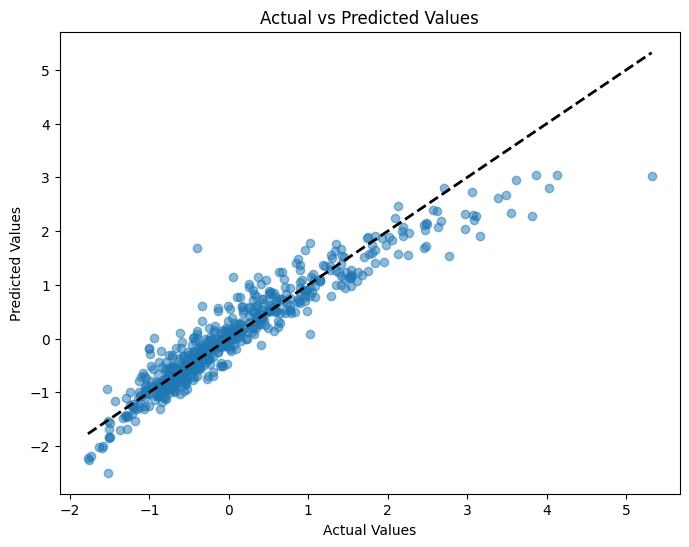

In [16]:
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of actual vs predicted values
ax.scatter(y_val, y_pred, alpha=0.5)

# Add a diagonal line for reference
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)

# Set labels and title
ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values')
ax.set_title('Actual vs Predicted Values')

# Show the plot
plt.show();

### Ridge regression

Let's try a **Ridge regression** now. Note that `sklearn` uses an $\alpha$ term, rather than $\lambda$, like in the text. The two are related. See the footnotes in Chapter 3. 

In John Hull’s textbook, this penalty is written using the symbol $\lambda$, but in `sklearn` Ridge regression, the equivalent parameter is called $\alpha$. As noted in the footnote in Chapter 3, Python’s Ridge implementation defines:
	
$\text{penalty term} = \alpha \sum_{j=1}^{k} \beta_j^2$

In contrast, Hull defines the Ridge penalty as:
	
$\frac{\lambda}{n} \sum_{j=1}^{k} \beta_j^2$

To align with Hull’s presentation, we multiply Hull’s  $\lambda$  by the number of observations $n$ to get the corresponding $\alpha$ for Python. If our training data has 1800 rows, then:

$\alpha = \lambda \times 1800$

The code below tries different values of $\alpha$, fits a Ridge regression for each, and reports the Mean Squared Error (MSE) on a validation set.

As $\alpha$ increases, the model applies more shrinkage to the coefficients — pulling them closer to zero. This reduces model complexity, which can help prevent overfitting, but it may also hurt performance if the penalty is too aggressive.

What we’re looking for is a sweet spot — a value of $\alpha$ large enough to reduce overfitting, but not so large that the model underfits.

In [17]:
# The alpha used by Python's ridge should be the lambda in Hull's book times the number of observations
alphas=[0.01*1800, 0.02*1800, 0.03*1800, 0.04*1800, 0.05*1800, 0.075*1800,0.1*1800,0.2*1800, 0.4*1800]
mses=[]
for alpha in alphas:
    ridge=Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    pred=ridge.predict(X_val)
    mses.append(mse(y_val,pred))
    print(mse(y_val,pred))

0.11703284346091337
0.11710797319752984
0.11723952924901117
0.11741457158889508
0.1176238406871146
0.11825709631198014
0.11900057469147927
0.1225464999629295
0.13073599680747128


After running this, you might want to plot the MSEs against $\alpha$ values to visualize the bias–variance tradeoff. You’re likely to see a U-shaped curve:

Small  $\alpha$  → low bias but high variance (potential overfitting)

Large  $\alpha$  → low variance but high bias (potential underfitting)

We’ll explore this more when we get to model tuning and cross-validation, where we pick the best value of $\alpha$ automatically.

Let's plot $\alpha$ values on the y-axis and MSE on the x-axis. 

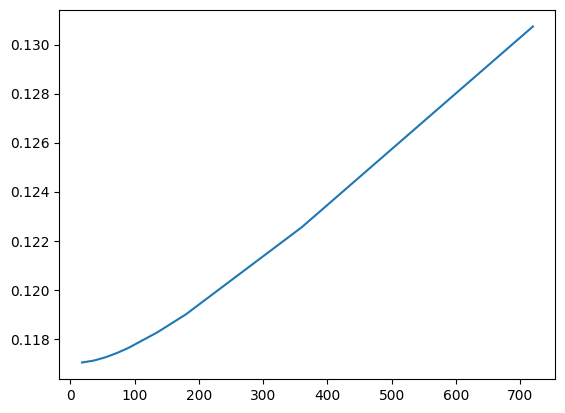

In [18]:
plt.plot(alphas, mses)

Note that this isn't exactly what's in the text. Figure 3.8 has $\lambda$ on the x-axis and Variance Unexplained on the y-axis. This plot gives the same information, though. 

### Lasso regression

Let's look at a **lasso regression**. We create the lasso object with a specific alpha hyperparameter. Then, we feed that object the necessary data. We'll use our training data.

Like Ridge, Lasso regression adds a penalty to the cost function, but instead of squaring the coefficients, it uses their absolute values. This subtle change has a major practical impact.

In `sklearn`, this is written using alpha instead of $\lambda$ , and the relationship is:

$\alpha = \frac{\lambda}{2}$

You can see this in the footnotes and equations in Hull’s Chapter 3. The division by 2 is how the penalty term is defined under the hood in `sklearn`. So, to align with Hull’s notation, if you want to use  $\lambda = 0.1$ , you set alpha = 0.05 in your Python code.

After fitting the model, try printing out lasso.coef_ — you’ll likely notice that some coefficients are exactly zero. That’s Lasso’s superpower: it performs automatic feature selection by shrinking some coefficients all the way to zero. This helps create simpler, more interpretable models, especially when many features are irrelevant or highly correlated.

This is particularly useful when you have a lot of predictors, and you want to focus on the most important ones.

In [19]:
# Here we produce results for alpha=0.05 which corresponds to lambda=0.1 in Hull's book
lasso = Lasso(alpha=0.05)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.05
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


We can output the model using this bit of code. Remember, model specifications are contained in the object created when we fit, or estimate, the model.

In [20]:
# DataFrame with corresponding feature and its respective coefficients
coeffs = pd.DataFrame(
    [
        ['intercept'] + list(X_train.columns),
        list(lasso.intercept_) + list(lasso.coef_)
    ]
).transpose().set_index(0)
coeffs

,1
0,
intercept,-0.0
LotArea,0.044304
OverallQual,0.298079
OverallCond,0.0
YearBuilt,0.052091
YearRemodAdd,0.064471
BsmtFinSF1,0.115875
BsmtUnfSF,-0.0
TotalBsmtSF,0.10312


Do you see all of the zero values? The lasso model penalizes features that are either unimportant or similar to other variables in the model. Notice how all of the negative weights are gone.

Just like we did with Ridge, let’s try a range of  $\lambda$  values (converted to alpha for Python). This allows us to evaluate how aggressive the Lasso penalty should be. Larger penalties will increase bias but reduce variance, and will eliminate more features.

In [21]:
# We now consider different lambda values. The alphas are half the lambdas
alphas=[0.01/2, 0.02/2, 0.03/2, 0.04/2, 0.05/2, 0.075/2, 0.1/2]
mses=[]
for alpha in alphas:
    lasso=Lasso(alpha=alpha)
    lasso.fit(X_train,y_train)
    pred=lasso.predict(X_val)
    mses.append(mse(y_val,pred))
    print(mse(y_val, pred))

0.11654751909608793
0.11682687945311095
0.11803348353132033
0.12012836764958999
0.12301536903084047
0.13178576395045638
0.1401719458448378


You can now examine:
- How the MSE changes as alpha increases
- How many coefficients are shrunk to zero for each alpha
- Whether there’s a tradeoff between model simplicity and predictive performance

Try printing np.sum(lasso.coef_ == 0) inside the loop if you want to track how many features are removed at each level of regularization.

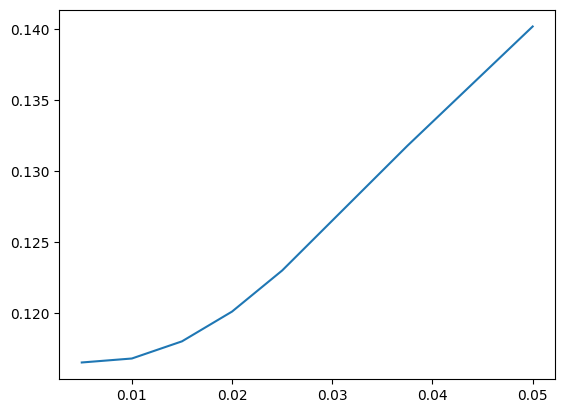

In [22]:
plt.plot(alphas, mses)

### Elastic net

The text comments that the elastic net model doesn't really give much of an improvement over lasso. Let's estimate it here, though.

In [23]:
elastic = ElasticNet(alpha=0.05, l1_ratio=0.8, fit_intercept=True)
elastic.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.8
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


We again create our model object and then fit it with data.

What do the `alpha` and `l1_ratio` parameters do? From Claude:

In the scikit-learn implementation of Elastic Net regression (ElasticNet class), the alpha and l1_ratio parameters control the strength and balance between the L1 (Lasso) and L2 (Ridge) regularization penalties, respectively.

- alpha (float): This parameter controls the overall strength of the regularization. A higher value of alpha increases the regularization effect, shrinking the coefficients more towards zero. When alpha=0, there is no regularization, and the model becomes an ordinary least squares linear regression.

- l1_ratio (float between 0 and 1): This parameter determines the balance between the L1 and L2 penalties in the Elastic Net regularization. Specifically: l1_ratio=1 means the penalty is an L1 penalty (Lasso). l1_ratio=0 means the penalty is an L2 penalty (Ridge). 0 < l1_ratio < 1 means the penalty is a combination of L1 and L2 penalties (Elastic Net).

So, alpha controls the overall regularization strength, while l1_ratio determines how much of that regularization comes from the L1 penalty vs the L2 penalty. In practice, you would tune both alpha and l1_ratio using cross-validation to find the best combination for your specific data. Common values for l1_ratio are 0.5 (balanced Elastic Net), 0.2, or 0.8 depending on whether you want more L2 or L1 regularization respectively.

Let's look.

In [24]:
# DataFrame with corresponding feature and its respective coefficients
coeffs = pd.DataFrame(
    [
        ['intercept'] + list(X_train.columns),
        list(elastic.intercept_) + list(elastic.coef_)
    ]
).transpose().set_index(0)
coeffs

,1
0,
intercept,-0.0
LotArea,0.051311
OverallQual,0.283431
OverallCond,0.005266
YearBuilt,0.059446
YearRemodAdd,0.067086
BsmtFinSF1,0.11673
BsmtUnfSF,-0.0
TotalBsmtSF,0.096558


Watch what happens when I set `l1_ratio` = 1. I get the lasso model!

In [25]:
elastic = ElasticNet(alpha=0.05, l1_ratio=1, fit_intercept=True)
elastic.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.05
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [26]:
coeffs = pd.DataFrame(
    [
        ['intercept'] + list(X_train.columns),
        list(elastic.intercept_) + list(elastic.coef_)
    ]
).transpose().set_index(0)
coeffs

,1
0,
intercept,-0.0
LotArea,0.044304
OverallQual,0.298079
OverallCond,0.0
YearBuilt,0.052091
YearRemodAdd,0.064471
BsmtFinSF1,0.115875
BsmtUnfSF,-0.0
TotalBsmtSF,0.10312
